In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import math

In [2]:
algos = ['baseline', 'hedging', 'linnos', 'flashnet', 'shinka']
percentiles_characteristics = ['avg', 'p50.0', 'p80.0', 'p90.0', 'p95.0', 'p96.0', 'p97.0', 'p98.0', 'p99.0', 'p99.9', 'p99.99']

In [3]:
grouping_dirs = {}
grouping_dirs['data'] = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))

## Examine the Stats

In [4]:
col_names = ['algo', 'grouping_dir', 'trace_dir'] + percentiles_characteristics
df = pd.DataFrame(columns = col_names)

for key, grouping_dir in grouping_dirs.items():
    trace_dirs_1 = [os.path.join(grouping_dir, dir) for dir in os.listdir(grouping_dir) if os.path.isdir(os.path.join(grouping_dir, dir))]
    trace_dirs_2 = []
    for trace_dir in trace_dirs_1:
        trace_dirs_2.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs_3 = []
    for trace_dir in trace_dirs_2:
        trace_dirs_3.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs_4 = []
    for trace_dir in trace_dirs_3:
        trace_dirs_4.extend([os.path.join(trace_dir, dir) for dir in os.listdir(trace_dir) if os.path.isdir(os.path.join(trace_dir, dir))])
    trace_dirs = trace_dirs_4

    for trace_dir in trace_dirs:
        for algo in algos:
            this_data = [algo, key, trace_dir]
            try:
                f = open(os.path.join(trace_dir, algo, "latency_characteristic.stats"), "r")
                latency_characteristic = f.readlines()
                for p in percentiles_characteristics:
                    for line in latency_characteristic:
                        if line.split(' = ')[0] == p:
                            this_data.append(float(line.split(' = ')[1].split(' us')[0]))
                df.loc[len(df)] = this_data
            except:
                print("CHAR", algo, trace_dir)

df

,algo,grouping_dir,trace_dir,avg,p50.0,p80.0,p90.0,p95.0,p96.0,p97.0,p98.0,p99.0,p99.9,p99.99
0,baseline,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,120.649952,99.0,151.0,217.0,286.95,310.0,341.0,387.00,455.0,597.000,976.4158
1,hedging,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,130.081338,108.0,165.0,232.0,298.00,321.0,352.0,395.00,462.0,585.000,676.0000
2,linnos,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,127.300334,103.0,149.0,192.0,253.00,277.0,307.0,354.00,437.0,660.000,943.7079
3,flashnet,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,131.570828,108.0,158.0,225.0,299.00,324.0,358.0,403.58,473.0,611.000,940.7079
4,shinka,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,94.696542,77.0,109.0,146.0,199.00,219.0,245.0,287.00,368.0,582.000,903.0000
5,baseline,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,302.113884,257.0,423.0,561.0,735.00,788.0,851.0,922.00,1039.0,1487.000,1981.0000
6,hedging,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,318.989388,268.0,446.0,597.0,778.00,836.0,904.0,989.00,1121.0,1547.000,1909.8893
7,linnos,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,200.788174,144.0,281.0,397.0,504.00,539.0,586.0,658.00,785.0,1192.000,1619.3692
8,flashnet,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,262.541962,192.0,389.0,522.0,686.00,746.0,821.0,915.00,1056.0,1554.204,2072.6204
9,shinka,data,/mnt/heimdall-exp/SSD-Heuristics/integration/c...,207.805836,168.0,309.0,389.0,465.00,489.0,520.0,568.00,665.0,1087.000,1616.0000


In [5]:
collection = df.groupby(['algo'])[percentiles_characteristics].mean().reindex(algos)
# convert value to ms
collection_ms = collection / 1000
collection_ms

,avg,p50.0,p80.0,p90.0,p95.0,p96.0,p97.0,p98.0,p99.0,p99.9,p99.99
algo,,,,,,,,,,,
baseline,0.170371,0.136667,0.239167,0.317500,0.403658,0.431333,0.465500,0.511333,0.585000,0.824833,1.254277
hedging,0.178508,0.143333,0.250333,0.332167,0.421000,0.449667,0.485833,0.535167,0.613167,0.804833,0.968940
linnos,0.144997,0.114500,0.185333,0.247500,0.314167,0.335000,0.362667,0.405167,0.480833,0.723333,1.095426
flashnet,0.151718,0.116000,0.199000,0.280000,0.366333,0.395833,0.434500,0.486263,0.568833,0.815367,1.207835
shinka,0.121724,0.097500,0.158333,0.212167,0.271000,0.291000,0.316833,0.356667,0.430667,0.676000,1.005986


/tmp/ipykernel_823152/4273236136.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label, rotation=90)


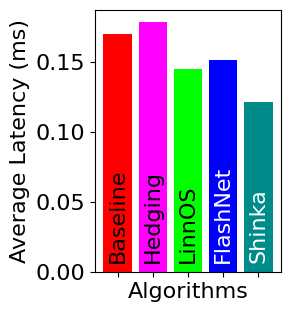

In [6]:
plt.rcParams.update({'font.size': 16})

algos = ['baseline', 'hedging', 'linnos', 'flashnet', 'shinka']
label = ['Baseline', 'Hedging', 'LinnOS', 'FlashNet', 'Shinka']
font_colors = ['black', 'black', 'black', 'white', 'white']
colors = ['red', 'magenta', 'lime', 'blue', 'darkcyan']

metric = "avg"

fig, ax = plt.subplots(figsize=(2.4, 3.4))
ax.bar(algos, collection_ms[metric], label=label, color=colors)
ax.set_ylabel('Average Latency (ms)')
ax.set_xticklabels(label, rotation=90)
ax.set_xlabel('Algorithms')
ax.tick_params(axis='x', which='major', pad=-10)
for ticklabel, tickcolor in zip(fig.gca().get_xticklabels(), font_colors):
    ticklabel.set_color(tickcolor)
    ticklabel.set_horizontalalignment("center")
    ticklabel.set_verticalalignment("bottom")
plt.savefig(os.path.join("eval-client-avg.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()

['Baseline', 'Hedging', 'LinnOS', 'FlashNet', 'Shinka']


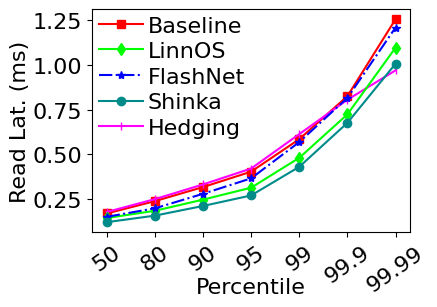

In [7]:
algos = ['baseline', 'hedging', 'linnos', 'flashnet', 'shinka']
line_legend = ['Baseline', 'Hedging', 'LinnOS', 'FlashNet', 'Shinka']
colors = ['red', 'magenta', 'lime', 'blue', 'darkcyan']
styles = ['s-', '|-', 'd-', '*-.', 'o-']

x_labels = ["avg", "p80.0", "p90.0", "p95.0", "p99.0", "p99.9", "p99.99"]
x_ticks = ["50", "80", "90", "95", "99", "99.9", "99.99"]

fig, ax = plt.subplots(figsize=(4.1, 2.9))
for idx, algo in enumerate(algos):
    ax.plot(np.arange(len(x_labels)), collection_ms.loc[algo][x_labels].values, styles[idx], label=line_legend[idx], color=colors[idx], linewidth=1.5)

handles, labels = ax.get_legend_handles_labels()
print(labels)

# Order: Baseline, LinnOS, FlashNet, Shinka, Hedging
ax.legend(
    [handles[0], handles[2], handles[3], handles[4], handles[1]],
    [labels[0],  labels[2],  labels[3],  labels[4],  labels[1]],
    loc='upper left', frameon=False, labelspacing=0.25, columnspacing=0.5,
    borderpad=-0.2, handletextpad=0.2, handlelength=2
)
ax.set_xticks(np.arange(len(x_ticks)), x_ticks)
ax.set_xticklabels(x_ticks, rotation=35, ha='center')
ax.set_ylabel("Read Lat. (ms)", labelpad=2)
ax.set_xlabel("Percentile")
ax.xaxis.set_label_coords(0.5, -0.2)
plt.savefig(os.path.join("eval-client-line.eps"), dpi=200, bbox_inches='tight', format='eps')
plt.show()

## Paired Diagnostics
Compare only trace directories that have results for both baseline and a given algorithm, and show whether the tail improvement is consistent or canceled out by regressions.

In [8]:
summary_metrics = ['avg', 'p95.0', 'p99.0', 'p99.9', 'p99.99']
compare_algos = ['flashnet', 'shinka']

for compare_algo in compare_algos:
    subset = df[df['algo'].isin(['baseline', compare_algo])].copy()
    paired = subset.pivot(index='trace_dir', columns='algo', values=percentiles_characteristics)
    paired = paired.dropna()

    if paired.empty:
        print(f"\n=== baseline vs {compare_algo}: no paired traces found ===")
        continue

    result = pd.DataFrame(index=summary_metrics)
    result['baseline_mean_ms'] = [paired[(metric, 'baseline')].mean() / 1000 for metric in summary_metrics]
    result[f'{compare_algo}_mean_ms'] = [paired[(metric, compare_algo)].mean() / 1000 for metric in summary_metrics]
    result['delta_pct'] = (
        (result[f'{compare_algo}_mean_ms'] - result['baseline_mean_ms'])
        / result['baseline_mean_ms'] * 100
    )
    result[f'{compare_algo}_better'] = [
        int((paired[(metric, compare_algo)] < paired[(metric, 'baseline')]).sum())
        for metric in summary_metrics
    ]
    result['baseline_better'] = [
        int((paired[(metric, compare_algo)] > paired[(metric, 'baseline')]).sum())
        for metric in summary_metrics
    ]

    print(f"\n=== baseline vs {compare_algo} ({len(paired)} paired traces) ===")
    display(result)


=== baseline vs flashnet (6 paired traces) ===


,baseline_mean_ms,flashnet_mean_ms,delta_pct,flashnet_better,baseline_better
avg,0.170371,0.151718,-10.948628,5,1
p95.0,0.403658,0.366333,-9.246681,5,1
p99.0,0.585000,0.568833,-2.763533,3,2
p99.9,0.824833,0.815367,-1.147626,4,2
p99.99,1.254277,1.207835,-3.702640,5,1



=== baseline vs shinka (6 paired traces) ===


,baseline_mean_ms,shinka_mean_ms,delta_pct,shinka_better,baseline_better
avg,0.170371,0.121724,-28.553438,6,0
p95.0,0.403658,0.271000,-32.864015,6,0
p99.0,0.585000,0.430667,-26.381766,6,0
p99.9,0.824833,0.676000,-18.044049,6,0
p99.99,1.254277,1.005986,-19.795499,6,0


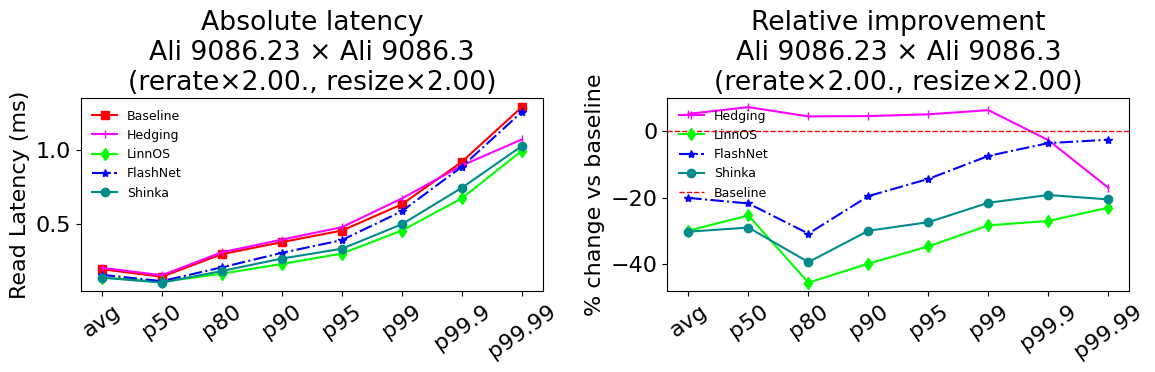


Trace: /mnt/heimdall-exp/SSD-Heuristics/integration/client-level/data/alibaba.per_3mins.iops_p75.alibaba_9086.23/alibaba.per_3mins.offset_p100.alibaba_9086.3/modified.rerate_0.50...modified.rerate_2.00.resize_2.00/nvme0n1...nvme1n1
Available algos: ['baseline', 'hedging', 'linnos', 'flashnet', 'shinka']


In [9]:
import re

# Individual trace deep-dive: percentile curve for all algos on one trace
# Change SELECTED_TRACE_IDX to examine a different trace

SELECTED_TRACE_IDX = 2   # 0..N-1

def short_label(trace_dir):
    from pathlib import Path
    parts = Path(trace_dir).parts
    def src_name(s):
        if 'tencent' in s: return 'Tencent'
        if 'alibaba' in s:
            m = re.search(r'alibaba_([\d.]+)', s)
            return f"Ali {m.group(1)}" if m else 'Alibaba'
        if 'msr' in s:
            m = re.search(r'(src1|prxy)_[\d.]+', s)
            return f"MSR {m.group(0)}" if m else 'MSR'
        return s.split('.')[-1][:12]
    src1 = src_name(parts[-4]) if len(parts) >= 4 else ''
    src2 = src_name(parts[-3]) if len(parts) >= 3 else ''
    cfg  = parts[-2].split('...')[-1] if len(parts) >= 2 else parts[-2]
    rerate = re.search(r'rerate_([\d.]+)', cfg)
    resize = re.search(r'resize_([\d.]+)', cfg)
    rw     = 'rw' if 'rw_ratio' in cfg else ''
    cfg_parts = []
    if rerate: cfg_parts.append(f"rerate×{rerate.group(1)}")
    if resize: cfg_parts.append(f"resize×{resize.group(1)}")
    if rw:     cfg_parts.append(rw)
    cfg_str = ', '.join(cfg_parts) or cfg[:20]
    return f"{src1} × {src2}\n({cfg_str})"

trace_dirs_sorted = sorted(df['trace_dir'].unique())
trace_labels = [short_label(t) for t in trace_dirs_sorted]

selected_trace = trace_dirs_sorted[SELECTED_TRACE_IDX]
selected_label = trace_labels[SELECTED_TRACE_IDX]

all_algos    = ['baseline', 'hedging', 'linnos', 'flashnet', 'shinka']
all_labels   = ['Baseline', 'Hedging', 'LinnOS', 'FlashNet', 'Shinka']
colors_all   = ['red', 'magenta', 'lime', 'blue', 'darkcyan']
styles_all   = ['s-', '|-', 'd-', '*-.', 'o-']

x_labels = ['avg', 'p50.0', 'p80.0', 'p90.0', 'p95.0', 'p99.0', 'p99.9', 'p99.99']
x_ticks  = ['avg', 'p50', 'p80', 'p90', 'p95', 'p99', 'p99.9', 'p99.99']

trace_df = df[df['trace_dir'] == selected_trace]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: absolute latency (ms)
for algo, label, color, style in zip(all_algos, all_labels, colors_all, styles_all):
    row = trace_df[trace_df['algo'] == algo]
    if row.empty:
        continue
    vals = [row.iloc[0][m] / 1000 for m in x_labels if not pd.isna(row.iloc[0][m])]
    ax1.plot(range(len(vals)), vals, style, label=label, color=color, linewidth=1.5)

ax1.set_xticks(range(len(x_ticks)))
ax1.set_xticklabels(x_ticks, rotation=35, ha='center')
ax1.set_ylabel('Read Latency (ms)')
ax1.set_title(f'Absolute latency\n{selected_label}')
ax1.legend(fontsize=9, frameon=False)

# Right: % change vs baseline
base_row = trace_df[trace_df['algo'] == 'baseline']
if not base_row.empty:
    for algo, label, color, style in zip(all_algos[1:], all_labels[1:], colors_all[1:], styles_all[1:]):
        row = trace_df[trace_df['algo'] == algo]
        if row.empty:
            continue
        pcts = []
        for m in x_labels:
            base_v = base_row.iloc[0][m]
            algo_v = row.iloc[0][m]
            if not pd.isna(base_v) and not pd.isna(algo_v) and base_v != 0:
                pcts.append((algo_v - base_v) / base_v * 100)
        ax2.plot(range(len(pcts)), pcts, style, label=label, color=color, linewidth=1.5)

    ax2.axhline(0, color='red', linestyle='--', linewidth=1, label='Baseline')
    ax2.set_xticks(range(len(x_ticks)))
    ax2.set_xticklabels(x_ticks, rotation=35, ha='center')
    ax2.set_ylabel('% change vs baseline')
    ax2.set_title(f'Relative improvement\n{selected_label}')
    ax2.legend(fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig(f'eval-trace-{SELECTED_TRACE_IDX}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTrace: {selected_trace}")
print(f"Available algos: {list(trace_df['algo'].unique())}")

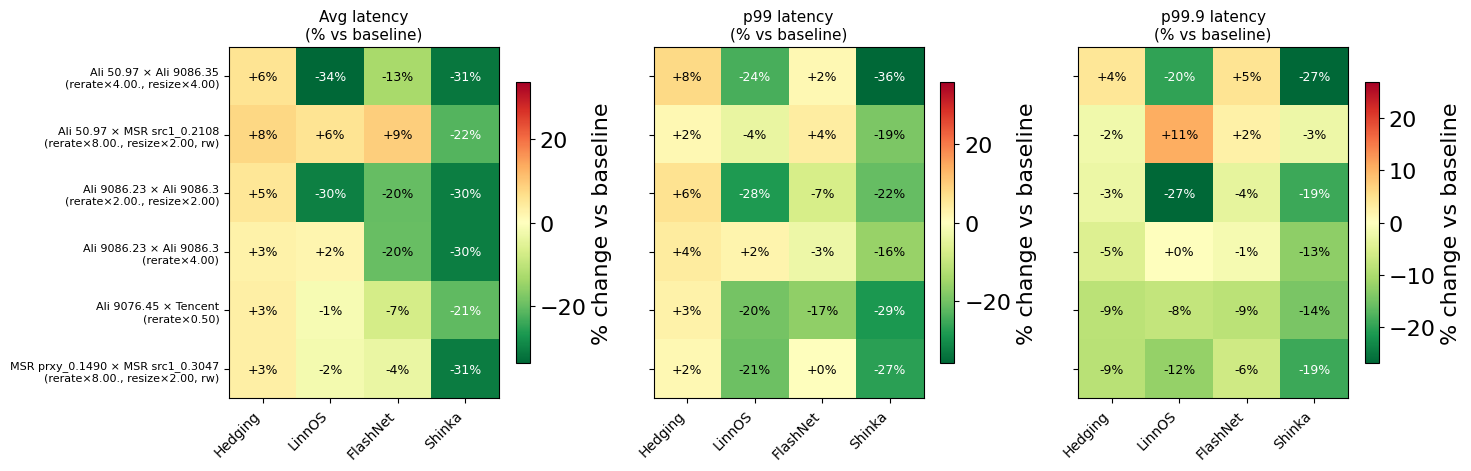

In [10]:
import re
import matplotlib.colors as mcolors

def short_label(trace_dir):
    from pathlib import Path
    parts = Path(trace_dir).parts
    def src_name(s):
        if 'tencent' in s: return 'Tencent'
        if 'alibaba' in s:
            m = re.search(r'alibaba_([\d.]+)', s)
            return f"Ali {m.group(1)}" if m else 'Alibaba'
        if 'msr' in s:
            m = re.search(r'(src1|prxy)_[\d.]+', s)
            return f"MSR {m.group(0)}" if m else 'MSR'
        return s.split('.')[-1][:12]
    src1 = src_name(parts[-4]) if len(parts) >= 4 else ''
    src2 = src_name(parts[-3]) if len(parts) >= 3 else ''
    cfg  = parts[-2].split('...')[-1] if len(parts) >= 2 else parts[-2]
    rerate = re.search(r'rerate_([\d.]+)', cfg)
    resize = re.search(r'resize_([\d.]+)', cfg)
    rw     = 'rw' if 'rw_ratio' in cfg else ''
    cfg_parts = []
    if rerate: cfg_parts.append(f"rerate×{rerate.group(1)}")
    if resize: cfg_parts.append(f"resize×{resize.group(1)}")
    if rw:     cfg_parts.append(rw)
    cfg_str = ', '.join(cfg_parts) or cfg[:20]
    return f"{src1} × {src2}\n({cfg_str})"

compare_algos = ['hedging', 'linnos', 'flashnet', 'shinka']
algo_labels   = ['Hedging', 'LinnOS', 'FlashNet', 'Shinka']
plot_metrics  = ['avg', 'p99.0', 'p99.9']
metric_labels = ['Avg', 'p99', 'p99.9']

trace_dirs_sorted = sorted(df['trace_dir'].unique())
trace_labels = [short_label(t) for t in trace_dirs_sorted]

fig, axes = plt.subplots(1, len(plot_metrics), figsize=(5 * len(plot_metrics), 5), sharey=True)

for ax, metric, mlabel in zip(axes, plot_metrics, metric_labels):
    matrix = []
    ytick_labels = []
    for trace_dir, label in zip(trace_dirs_sorted, trace_labels):
        trace_df = df[df['trace_dir'] == trace_dir]
        base_row = trace_df[trace_df['algo'] == 'baseline']
        if base_row.empty or pd.isna(base_row.iloc[0][metric]):
            continue
        base_val = base_row.iloc[0][metric]
        row_vals = []
        for algo in compare_algos:
            algo_row = trace_df[trace_df['algo'] == algo]
            if not algo_row.empty and not pd.isna(algo_row.iloc[0][metric]):
                val = algo_row.iloc[0][metric]
                row_vals.append((val - base_val) / base_val * 100)
            else:
                row_vals.append(np.nan)
        matrix.append(row_vals)
        ytick_labels.append(label)

    matrix = np.array(matrix, dtype=float)
    vmax = max(abs(np.nanmin(matrix)), abs(np.nanmax(matrix)), 5)
    im = ax.imshow(matrix, cmap='RdYlGn_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(compare_algos)))
    ax.set_xticklabels(algo_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(len(ytick_labels)))
    ax.set_yticklabels(ytick_labels, fontsize=8)
    ax.set_title(f'{mlabel} latency\n(% vs baseline)', fontsize=11)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:+.0f}%', ha='center', va='center', fontsize=9,
                        color='black' if abs(val) < vmax * 0.6 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8, label='% change vs baseline')

plt.tight_layout()
plt.savefig('eval-client-heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
compare_algos = ['hedging', 'linnos', 'flashnet', 'shinka']
summary_metrics = ['avg', 'p95.0', 'p99.0', 'p99.9', 'p99.99']

def short_label(trace_dir):
    from pathlib import Path
    parts = Path(trace_dir).parts
    def src_name(s):
        if 'tencent' in s: return 'Tencent'
        if 'alibaba' in s:
            m = re.search(r'alibaba_([\d.]+)', s)
            return f"Ali {m.group(1)}" if m else 'Alibaba'
        if 'msr' in s:
            m = re.search(r'(src1|prxy)_[\d.]+', s)
            return f"MSR {m.group(0)}" if m else 'MSR'
        return s.split('.')[-1][:12]
    src1 = src_name(parts[-4]) if len(parts) >= 4 else ''
    src2 = src_name(parts[-3]) if len(parts) >= 3 else ''
    cfg  = parts[-2].split('...')[-1] if len(parts) >= 2 else parts[-2]
    rerate = re.search(r'rerate_([\d.]+)', cfg)
    resize = re.search(r'resize_([\d.]+)', cfg)
    rw     = 'rw' if 'rw_ratio' in cfg else ''
    cfg_parts = []
    if rerate: cfg_parts.append(f"rerate×{rerate.group(1)}")
    if resize: cfg_parts.append(f"resize×{resize.group(1)}")
    if rw:     cfg_parts.append(rw)
    cfg_str = ', '.join(cfg_parts) or cfg[:20]
    return f"{src1} × {src2} ({cfg_str})"

trace_dirs_sorted = sorted(df['trace_dir'].unique())
trace_labels = [short_label(t) for t in trace_dirs_sorted]

for metric in summary_metrics:
    rows = []
    for trace_dir, label in zip(trace_dirs_sorted, trace_labels):
        trace_df = df[df['trace_dir'] == trace_dir]
        base_row = trace_df[trace_df['algo'] == 'baseline']
        if base_row.empty or pd.isna(base_row.iloc[0][metric]):
            continue
        base_val = base_row.iloc[0][metric]
        row = {'trace': label, 'baseline_us': round(base_val)}
        for algo in compare_algos:
            algo_row = trace_df[trace_df['algo'] == algo]
            if not algo_row.empty and not pd.isna(algo_row.iloc[0][metric]):
                val = algo_row.iloc[0][metric]
                row[algo] = f"{(val - base_val) / base_val * 100:+.1f}%"
            else:
                row[algo] = "—"
        rows.append(row)

    result_df = pd.DataFrame(rows).set_index('trace')
    print(f"\n=== Relative improvement vs baseline at {metric} ===")
    display(result_df)


=== Relative improvement vs baseline at avg ===


,baseline_us,hedging,linnos,flashnet,shinka
trace,,,,,
"Ali 50.97 × Ali 9086.35 (rerate×4.00., resize×4.00)",302,+5.6%,-33.5%,-13.1%,-31.2%
"Ali 50.97 × MSR src1_0.2108 (rerate×8.00., resize×2.00, rw)",121,+7.8%,+5.5%,+9.1%,-21.5%
"Ali 9086.23 × Ali 9086.3 (rerate×2.00., resize×2.00)",189,+5.2%,-29.9%,-20.1%,-30.2%
Ali 9086.23 × Ali 9086.3 (rerate×4.00),165,+2.8%,+2.1%,-19.8%,-30.3%
Ali 9076.45 × Tencent (rerate×0.50),107,+3.3%,-1.5%,-7.1%,-20.6%
"MSR prxy_0.1490 × MSR src1_0.3047 (rerate×8.00., resize×2.00, rw)",138,+3.3%,-2.0%,-3.6%,-30.6%



=== Relative improvement vs baseline at p95.0 ===


,baseline_us,hedging,linnos,flashnet,shinka
trace,,,,,
"Ali 50.97 × Ali 9086.35 (rerate×4.00., resize×4.00)",735,+5.9%,-31.4%,-6.7%,-36.7%
"Ali 50.97 × MSR src1_0.2108 (rerate×8.00., resize×2.00, rw)",287,+3.9%,-11.8%,+4.2%,-30.6%
"Ali 9086.23 × Ali 9086.3 (rerate×2.00., resize×2.00)",453,+5.1%,-34.7%,-14.3%,-27.4%
Ali 9086.23 × Ali 9086.3 (rerate×4.00),362,+3.0%,+0.6%,-10.8%,-23.5%
Ali 9076.45 × Tencent (rerate×0.50),261,+3.8%,-29.5%,-26.4%,-38.3%
"MSR prxy_0.1490 × MSR src1_0.3047 (rerate×8.00., resize×2.00, rw)",324,+1.9%,-12.3%,-4.3%,-39.8%



=== Relative improvement vs baseline at p99.0 ===


,baseline_us,hedging,linnos,flashnet,shinka
trace,,,,,
"Ali 50.97 × Ali 9086.35 (rerate×4.00., resize×4.00)",1039,+7.9%,-24.4%,+1.6%,-36.0%
"Ali 50.97 × MSR src1_0.2108 (rerate×8.00., resize×2.00, rw)",455,+1.5%,-4.0%,+4.0%,-19.1%
"Ali 9086.23 × Ali 9086.3 (rerate×2.00., resize×2.00)",632,+6.3%,-28.3%,-7.4%,-21.5%
Ali 9086.23 × Ali 9086.3 (rerate×4.00),469,+4.3%,+2.3%,-3.2%,-16.0%
Ali 9076.45 × Tencent (rerate×0.50),415,+2.9%,-19.8%,-16.9%,-28.7%
"MSR prxy_0.1490 × MSR src1_0.3047 (rerate×8.00., resize×2.00, rw)",500,+1.6%,-20.6%,+0.0%,-27.0%



=== Relative improvement vs baseline at p99.9 ===


,baseline_us,hedging,linnos,flashnet,shinka
trace,,,,,
"Ali 50.97 × Ali 9086.35 (rerate×4.00., resize×4.00)",1487,+4.0%,-19.8%,+4.5%,-26.9%
"Ali 50.97 × MSR src1_0.2108 (rerate×8.00., resize×2.00, rw)",597,-2.0%,+10.6%,+2.3%,-2.5%
"Ali 9086.23 × Ali 9086.3 (rerate×2.00., resize×2.00)",922,-2.7%,-27.0%,-3.6%,-19.2%
Ali 9086.23 × Ali 9086.3 (rerate×4.00),651,-4.8%,+0.2%,-1.4%,-12.7%
Ali 9076.45 × Tencent (rerate×0.50),605,-8.6%,-7.6%,-8.6%,-14.4%
"MSR prxy_0.1490 × MSR src1_0.3047 (rerate×8.00., resize×2.00, rw)",687,-8.7%,-12.1%,-6.4%,-19.1%



=== Relative improvement vs baseline at p99.99 ===


,baseline_us,hedging,linnos,flashnet,shinka
trace,,,,,
"Ali 50.97 × Ali 9086.35 (rerate×4.00., resize×4.00)",1981,-3.6%,-18.3%,+4.6%,-18.4%
"Ali 50.97 × MSR src1_0.2108 (rerate×8.00., resize×2.00, rw)",976,-30.8%,-3.3%,-3.7%,-7.5%
"Ali 9086.23 × Ali 9086.3 (rerate×2.00., resize×2.00)",1296,-17.1%,-23.0%,-2.6%,-20.5%
Ali 9086.23 × Ali 9086.3 (rerate×4.00),1029,-30.0%,-3.6%,-1.8%,-9.3%
Ali 9076.45 × Tencent (rerate×0.50),1009,-35.4%,-8.3%,-9.1%,-10.9%
"MSR prxy_0.1490 × MSR src1_0.3047 (rerate×8.00., resize×2.00, rw)",1234,-36.7%,-11.4%,-15.5%,-46.9%


## Per-Trace Analysis
The averages above mask per-trace differences because traces have very different baseline latencies (107–302 µs). These cells show relative improvement vs baseline per trace, which is the right view for a paper.

## Shinka Evolution Scores
Score progression across generations for the selected trace (uses the same `SELECTED_TRACE_IDX` as the per-trace deep-dive above).

Traces with evolution data:
  [0] Ali 50.97 × Ali 9086.35 (rerate×4.00., resize×4.00)
  [1] Ali 50.97 × MSR src1_0.2108 (rerate×8.00., resize×2.00, rw)
  [2] Ali 9086.23 × Ali 9086.3 (rerate×2.00., resize×2.00) <-- SELECTED
  [3] Ali 9086.23 × Ali 9086.3 (rerate×4.00)
  [4] Ali 9076.45 × Tencent (rerate×0.50)
  [5] MSR prxy_0.1490 × MSR src1_0.3047 (rerate×8.00., resize×2.00, rw)


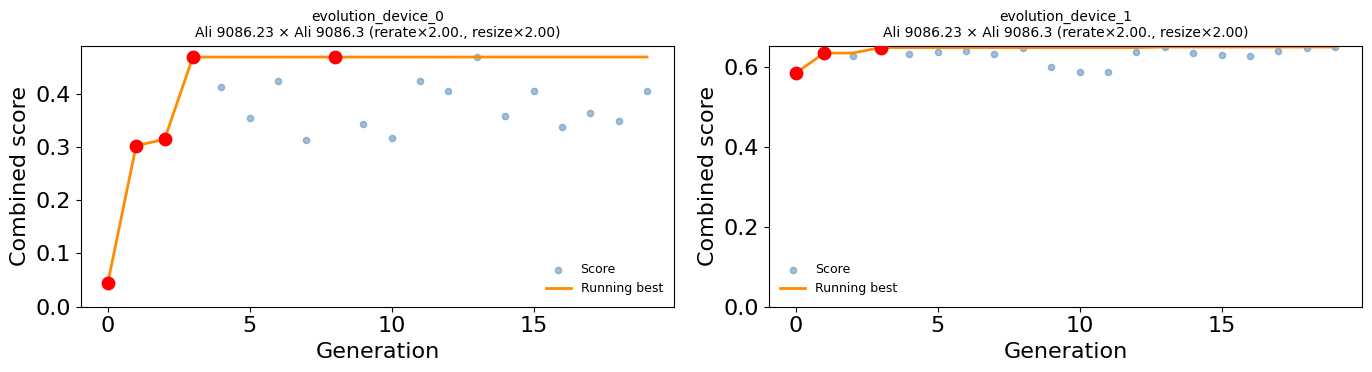

In [12]:
import re

SELECTED_TRACE_IDX = 2   # 0..N-1  (change here or in the per-trace deep-dive cell above)

def parse_evolution_log(log_path):
    scores = []
    best_at_gen = set()
    gen_counter = 0
    with open(log_path) as f:
        for line in f:
            m = re.search(r'added to DB - score: ([0-9.]+?)\.?\s*$', line)
            if m:
                scores.append((gen_counter, float(m.group(1))))
                gen_counter += 1
            m2 = re.search(r'New best program.*gen: (\d+)', line)
            if m2:
                best_at_gen.add(int(m2.group(1)))
    return scores, best_at_gen

def get_evo_dirs(trace_dir):
    evo_dir = os.path.join(trace_dir, 'shinka', 'training_results')
    if not os.path.isdir(evo_dir):
        return evo_dir, []
    return evo_dir, sorted([
        d for d in os.listdir(evo_dir)
        if d.startswith('evolution_device_') and os.path.isdir(os.path.join(evo_dir, d))
    ])

trace_dirs_sorted = sorted(df['trace_dir'].unique())
selected_trace = trace_dirs_sorted[SELECTED_TRACE_IDX]
selected_label = short_label(selected_trace)

# Show which indices have evolution data
print("Traces with evolution data:")
for i, t in enumerate(trace_dirs_sorted):
    _, devs = get_evo_dirs(t)
    if devs:
        marker = " <-- SELECTED" if i == SELECTED_TRACE_IDX else ""
        print(f"  [{i}] {short_label(t).replace(chr(10), ' ')}{marker}")

evo_dir, device_dirs = get_evo_dirs(selected_trace)

if not device_dirs:
    print(f"\nNo evolution data for SELECTED_TRACE_IDX={SELECTED_TRACE_IDX} ({selected_label.replace(chr(10), ' ')})")
    print("Change SELECTED_TRACE_IDX to one of the indices listed above.")
else:
    n_devices = len(device_dirs)
    fig, axes = plt.subplots(1, n_devices, figsize=(7 * n_devices, 4), squeeze=False)

    for ax, dev_dir in zip(axes[0], device_dirs):
        log_path = os.path.join(evo_dir, dev_dir, 'evolution_run.log')
        if not os.path.exists(log_path):
            ax.set_title(f'{dev_dir}\n(no log found)')
            continue

        scores, best_gens = parse_evolution_log(log_path)
        if not scores:
            ax.set_title(f'{dev_dir}\n(empty log)')
            continue

        gens   = [s[0] for s in scores]
        values = [s[1] for s in scores]

        running_best = []
        cur_best = -1
        for v in values:
            cur_best = max(cur_best, v)
            running_best.append(cur_best)

        ax.scatter(gens, values, s=20, alpha=0.5, color='steelblue', label='Score')
        ax.plot(gens, running_best, color='darkorange', linewidth=2, label='Running best')

        for g, v in scores:
            if g in best_gens:
                ax.scatter(g, v, s=80, color='red', zorder=5, label='_nolegend_')

        ax.set_xlabel('Generation')
        ax.set_ylabel('Combined score')
        ax.set_title(f'{dev_dir}\n{selected_label}', fontsize=10)
        ax.legend(fontsize=9, frameon=False)
        ax.set_ylim(bottom=0)

    plt.tight_layout()
    plt.savefig(f'eval-evo-trace-{SELECTED_TRACE_IDX}.png', dpi=150, bbox_inches='tight')
    plt.show()